### ============================================================
### Lecture 1: Cross-sectional vs Time Series vs Panel Data
### Data source: Yahoo Finance (via yfinance)  —  S&P 500 Stocks
### ============================================================

> **What this notebook does:**
> Uses real U.S. stock market data (2020–2024) to illustrate the three
> fundamental data structures in forecasting.
>
> | Structure | Entities | Time points | Key question |
> |-----------|----------|-------------|--------------|
> | Cross-sectional | n > 1 | t = 1 | How do stocks compare *right now*? |
> | Time series | n = 1 | t > 1 | How does one stock evolve *over time*? |
> | Panel | n > 1 | t > 1 | Both simultaneously |


In [12]:
!pip install yfinance numpy pandas matplotlib --quiet

#### -----------------------------
#### 0.  Imports, Config & Style
#### -----------------------------


In [13]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

# ── tickers ──────────────────────────────────────────────────────────────────
TICKERS_20 = [
    'AAPL','MSFT','NVDA','AMZN','GOOGL',
    'META','BRK-B','LLY','AVGO','JPM',
    'V','TSLA','UNH','XOM','MA',
    'HD','COST','PG','JNJ','WMT',
]
TICKERS_10 = ['AAPL','MSFT','NVDA','AMZN','GOOGL','META','TSLA','JPM','V','XOM']
SP500      = '^GSPC'
VIX        = '^VIX'

START = '2020-01-01'
END   = '2024-12-31'

# ── colour palette ────────────────────────────────────────────────────────────
C_UP   = '#2ca25f'    # positive return / green
C_DOWN = '#d7301f'    # negative return / red
C_BLUE = '#2166AC'    # neutral / reference
C_GRAY = '#888888'
C_GOLD = '#E6A817'

plt.rcParams.update({
    'figure.facecolor': 'white',  'axes.facecolor': '#F9F9F9',
    'axes.edgecolor':   '#CCCCCC','axes.grid': True,
    'grid.color':       '#EEEEEE','grid.linewidth': 0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,        'axes.labelsize': 10,
    'xtick.labelsize':  8,         'ytick.labelsize': 8,
})


#### -----------------------------
#### 1.  Download Data
#### -----------------------------


In [14]:
# ── download adjusted close prices for all 20 stocks ─────────────────────
raw = yf.download(
    TICKERS_20 + [SP500, VIX],
    start=START, end=END,
    auto_adjust=True,
    progress=False,
)
prices = raw['Close'][TICKERS_20].dropna(how='all')
sp500  = raw['Close'][SP500].dropna()
vix    = raw['Close'][VIX].dropna()

# ── daily log-returns ─────────────────────────────────────────────────────
rets   = prices.pct_change().dropna()
sp_ret = sp500.pct_change().dropna()

# ── align all to common trading days ─────────────────────────────────────
common = rets.index.intersection(sp_ret.index).intersection(vix.index)
prices = prices.loc[common]
rets   = rets.loc[common]
sp500  = sp500.loc[common]
sp_ret = sp_ret.loc[common]
vix    = vix.loc[common]
dates  = common

print(f'Price data  : {prices.shape[0]} trading days  '
      f'({dates[0].date()} → {dates[-1].date()})')
print(f'Stocks      : {prices.shape[1]}')
print(f'S&P 500     : {sp500.shape[0]} observations')
print(f'VIX         : {vix.shape[0]} observations')
print()
display(prices.tail(3).round(2))


Price data  : 1256 trading days  (2020-01-03 → 2024-12-30)
Stocks      : 20
S&P 500     : 1256 observations
VIX         : 1256 observations



Ticker,AAPL,MSFT,NVDA,AMZN,GOOGL,META,BRK-B,LLY,AVGO,JPM,V,TSLA,UNH,XOM,MA,HD,COST,PG,JNJ,WMT
Date,,,,,,,,,,,,,,,,,,,,
2024-12-26,257.61,433.91,139.89,227.05,194.84,601.45,459.08,786.95,243.16,237.03,317.99,454.13,498.86,102.04,532.29,385.53,951.18,164.61,140.51,91.91
2024-12-27,254.20,426.40,136.97,223.75,192.01,597.92,456.51,776.08,239.59,235.11,315.76,431.66,497.73,102.03,528.37,383.30,934.82,164.00,140.00,90.79
2024-12-30,250.83,420.76,137.45,221.30,190.49,589.38,452.16,766.83,233.47,233.31,312.44,417.41,495.60,101.34,521.76,379.96,917.42,161.64,138.35,89.71


---
## Block 1 — Cross-sectional Data  (n > 1, t = 1)

**What it is:** A snapshot of many stocks at exactly one point in time.
Every row is a different stock; every column is an attribute measured on that single day.

| Dimension | Value |
|-----------|-------|
| Entities (n) | 20 S&P 500 stocks |
| Time points (t) | 1 trading day |
| Key question | *How do stocks compare against each other right now?* |


##### Build the cross-sectional snapshot


In [15]:
# Snapshot date: first trading day of 2024
SNAP_DATE = dates[dates >= '2024-01-05'][0]
print(f'Snapshot date: {SNAP_DATE.date()}')

snap_ret  = rets.loc[SNAP_DATE] * 100           # daily return in %
snap_px   = prices.loc[SNAP_DATE]               # closing price
snap_vol  = raw['Volume'][TICKERS_20].loc[SNAP_DATE]   # shares traded
snap_mcap = snap_px * snap_vol / 1e9            # rough proxy for dollar volume (billions)

cross = pd.DataFrame({
    'return_pct':  snap_ret,
    'close_price': snap_px,
    'volume':      snap_vol,
    'dollar_vol_B':snap_mcap,
}).sort_values('return_pct', ascending=False)

print(f'Cross-sectional shape: {cross.shape}   → n = {cross.shape[0]} stocks, t = 1 day')
display(cross.round(3))


Snapshot date: 2024-01-05
Cross-sectional shape: (20, 4)   → n = 20 stocks, t = 1 day


,return_pct,close_price,volume,dollar_vol_B
Ticker,,,,
NVDA,2.290,49.070,415039000,20.366
META,1.391,349.509,13920700,4.865
HD,1.285,326.598,2664300,0.870
COST,1.181,648.815,2233500,1.449
LLY,0.659,608.973,2404000,1.464
BRK-B,0.525,365.590,2965200,1.084
JPM,0.502,165.036,10066000,1.661
AMZN,0.463,145.240,45153100,6.558
JNJ,0.311,150.745,5602500,0.845


##### Plot 1 — Cross-sectional: returns, return vs dollar volume, and distribution


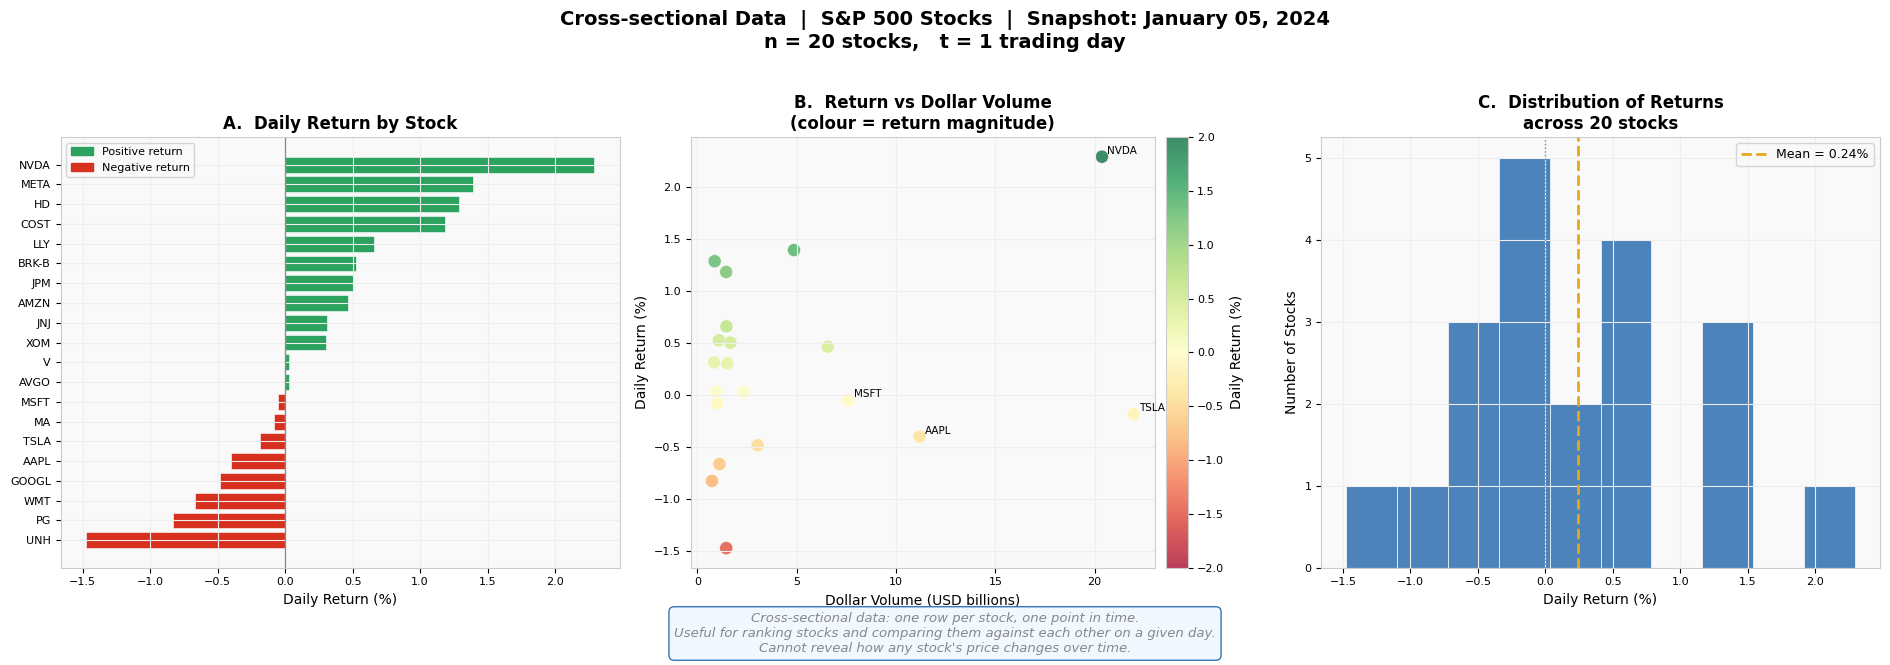

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(
    f'Cross-sectional Data  |  S&P 500 Stocks  |  Snapshot: {SNAP_DATE.strftime("%B %d, %Y")}\n'
    'n = 20 stocks,   t = 1 trading day',
    fontsize=14, fontweight='bold', y=1.02)

# ── A: horizontal bar — daily returns (green = positive, red = negative) ──
ax = axes[0]
sorted_ret  = cross['return_pct'].sort_values()
colors_bar  = [C_UP if v >= 0 else C_DOWN for v in sorted_ret]
ax.barh(sorted_ret.index, sorted_ret.values,
        color=colors_bar, edgecolor='white', linewidth=0.4)
ax.axvline(0, color=C_GRAY, lw=0.9)
ax.set_xlabel('Daily Return (%)')
ax.set_title('A.  Daily Return by Stock', fontweight='bold')
patch_up   = mpatches.Patch(color=C_UP,   label='Positive return')
patch_down = mpatches.Patch(color=C_DOWN, label='Negative return')
ax.legend(handles=[patch_up, patch_down], fontsize=8)

# ── B: scatter — dollar volume vs return, colour = return magnitude ────────
ax = axes[1]
sc = ax.scatter(
    cross['dollar_vol_B'],
    cross['return_pct'],
    s=90, alpha=0.75,
    c=cross['return_pct'], cmap='RdYlGn', vmin=-2, vmax=2,
    edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Daily Return (%)', pad=0.02)
for tk in ['AAPL', 'MSFT', 'NVDA', 'TSLA']:
    if tk in cross.index:
        ax.annotate(tk,
                    (cross.loc[tk,'dollar_vol_B'], cross.loc[tk,'return_pct']),
                    fontsize=7.5, ha='left',
                    xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Dollar Volume (USD billions)')
ax.set_ylabel('Daily Return (%)')
ax.set_title('B.  Return vs Dollar Volume\n(colour = return magnitude)',
             fontweight='bold')

# ── C: histogram — distribution of returns across all 20 stocks ───────────
ax = axes[2]
ax.hist(cross['return_pct'].values, bins=10, color=C_BLUE,
        edgecolor='white', linewidth=0.6, alpha=0.8)
ax.axvline(cross['return_pct'].mean(), color=C_GOLD, lw=2.0, ls='--',
           label=f"Mean = {cross['return_pct'].mean():.2f}%")
ax.axvline(0, color=C_GRAY, lw=1.0, ls=':')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Number of Stocks')
ax.set_title('C.  Distribution of Returns\nacross 20 stocks', fontweight='bold')
ax.legend(fontsize=9)

note = (
    'Cross-sectional data: one row per stock, one point in time.\n'
    'Useful for ranking stocks and comparing them against each other on a given day.\n'
    'Cannot reveal how any stock\'s price changes over time.'
)
fig.text(0.5, -0.05, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
plt.tight_layout()
plt.show()


---
## Block 2 — Time-series Data  (n = 1, t > 1)

**What it is:** One entity — the S&P 500 index — tracked every trading day
from January 2020 through December 2024.

| Dimension | Value |
|-----------|-------|
| Entities (n) | 1 index |
| Time points (t) | ~1,304 trading days |
| Key question | *How does the market evolve over time?* |

> **Three views of the same time series:**
> price level (trend), daily returns (volatility), rolling volatility (regime).


##### Build time-series features


In [17]:
# 30-day rolling annualised volatility
roll_vol = sp_ret.rolling(30).std() * np.sqrt(252) * 100

print(f'Time-series shape: {sp500.shape}  → n = 1 index, t = {len(sp500)} days')
display(pd.DataFrame({
    'SP500_price': sp500,
    'SP500_return_%': sp_ret*100,
    'Rolling_vol_%': roll_vol,
}).tail(8).round(3))


Time-series shape: (1256,)  → n = 1 index, t = 1256 days


,SP500_price,SP500_return_%,Rolling_vol_%
Date,,,
2024-12-18,5872.16,-2.949,13.745
2024-12-19,5867.08,-0.087,11.571
2024-12-20,5930.85,1.087,11.812
2024-12-23,5974.07,0.729,11.958
2024-12-24,6040.04,1.104,12.385
2024-12-26,6037.59,-0.041,12.351
2024-12-27,5970.84,-1.106,12.784
2024-12-30,5906.94,-1.070,13.042


##### Plot 2 — Time series: price, daily returns, rolling volatility


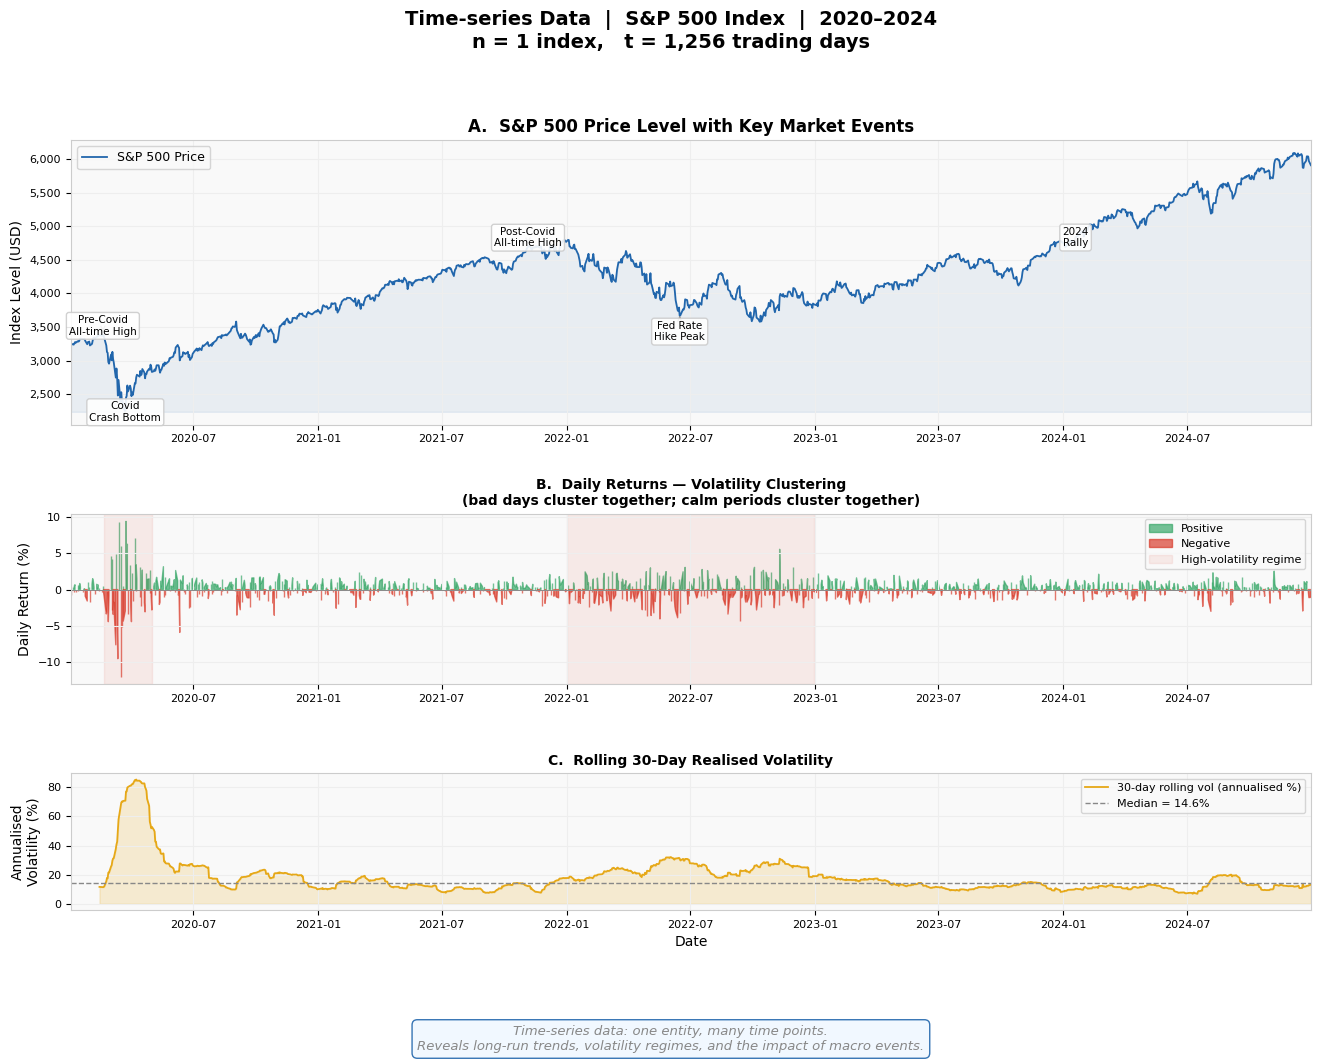

In [18]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                        height_ratios=[2.5, 1.5, 1.2])
fig.suptitle(
    'Time-series Data  |  S&P 500 Index  |  2020–2024\n'
    f'n = 1 index,   t = {len(sp500):,} trading days',
    fontsize=14, fontweight='bold', y=1.01)

# ── A: price level with annotated macro events ────────────────────────────
ax = fig.add_subplot(gs[0])
ax.plot(sp500.index, sp500, color=C_BLUE, lw=1.3, label='S&P 500 Price')
ax.fill_between(sp500.index, sp500, sp500.min(), alpha=0.08, color=C_BLUE)

events = [
    ('2020-02-19', 3386, 'Pre-Covid\nAll-time High'),
    ('2020-03-23', 2100, 'Covid\nCrash Bottom'),
    ('2021-11-05', 4698, 'Post-Covid\nAll-time High'),
    ('2022-06-16', 3300, 'Fed Rate\nHike Peak'),
    ('2024-01-19', 4700, '2024\nRally'),
]
for ds, y_ann, lbl in events:
    xv = pd.Timestamp(ds)
    if xv in sp500.index:
        yv = sp500.loc[xv]
    else:
        yv = sp500.asof(xv)
    ax.annotate(lbl, xy=(xv, yv), xytext=(xv, y_ann),
                arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.0),
                fontsize=7.5, ha='center', color='black',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#CCCCCC', alpha=0.9))
ax.set_ylabel('Index Level (USD)')
ax.set_title('A.  S&P 500 Price Level with Key Market Events', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=9)
ax.set_xlim(sp500.index[0], sp500.index[-1])

# ── B: daily returns — shows volatility clustering ────────────────────────
ax = fig.add_subplot(gs[1])
ax.fill_between(sp_ret.index, sp_ret*100, 0,
                where=sp_ret>=0, color=C_UP,   alpha=0.65, label='Positive')
ax.fill_between(sp_ret.index, sp_ret*100, 0,
                where=sp_ret<0,  color=C_DOWN, alpha=0.65, label='Negative')
ax.axhline(0, color=C_GRAY, lw=0.7)
# shade high-volatility regimes
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-05-01'),
           alpha=0.08, color=C_DOWN, label='High-volatility regime')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color=C_DOWN)
ax.set_ylabel('Daily Return (%)')
ax.set_title('B.  Daily Returns — Volatility Clustering\n'
             '(bad days cluster together; calm periods cluster together)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(sp_ret.index[0], sp_ret.index[-1])

# ── C: rolling 30-day realised volatility ────────────────────────────────
ax = fig.add_subplot(gs[2])
ax.plot(roll_vol.index, roll_vol, color=C_GOLD, lw=1.3,
        label='30-day rolling vol (annualised %)')
ax.fill_between(roll_vol.index, roll_vol, 0, alpha=0.18, color=C_GOLD)
ax.axhline(roll_vol.median(), color=C_GRAY, lw=1.0, ls='--',
           label=f'Median = {roll_vol.median():.1f}%')
ax.set_ylabel('Annualised\nVolatility (%)')
ax.set_title('C.  Rolling 30-Day Realised Volatility', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
ax.set_xlim(roll_vol.index[0], roll_vol.index[-1])
ax.set_xlabel('Date')

note = (
    'Time-series data: one entity, many time points.\n'
    'Reveals long-run trends, volatility regimes, and the impact of macro events.'
)
fig.text(0.5, -0.03, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
plt.show()


---
## Block 3 — Panel Data  (n > 1, t > 1)

**What it is:** Multiple stocks tracked over the full 5-year period.
This gives us both the cross-sectional breadth of Block 1 and the
time-series depth of Block 2 — simultaneously.

| Dimension | Value |
|-----------|-------|
| Entities (n) | 10 stocks |
| Time points (t) | ~1,304 trading days |
| Total observations | ~13,040 rows |
| Key question | *How does each stock perform — and how do they compare over time?* |


##### Build panel features


In [19]:
px10   = prices[TICKERS_10]
ret10  = rets[TICKERS_10]

# normalise all prices to 100 on day 1 (makes comparison fair)
px_norm = px10.div(px10.iloc[0]) * 100

# annual returns: compound daily returns within each calendar year
ret10_y = ret10.copy()
ret10_y['year'] = ret10.index.year
ann_ret = (
    ret10_y.groupby('year')[TICKERS_10]
    .apply(lambda df: (1 + df).prod() - 1) * 100
)

# full-period daily return correlation matrix
corr = ret10.corr()

print(f'Panel shape   : {ret10.shape}   → n = {len(TICKERS_10)} stocks, t = {len(ret10)} days')
print(f'Annual returns (%):')
display(ann_ret.round(1))


Panel shape   : (1256, 10)   → n = 10 stocks, t = 1256 days
Annual returns (%):


Ticker,AAPL,MSFT,NVDA,AMZN,GOOGL,META,TSLA,JPM,V,XOM
year,,,,,,,,,,
2020,78.2,39.9,118.0,71.6,28.1,30.2,720.1,-6.7,15.2,-37.2
2021,34.6,52.5,125.5,2.4,65.3,23.1,49.8,27.7,-0.3,57.6
2022,-26.4,-28.0,-50.3,-49.6,-39.1,-64.2,-65.0,-12.6,-3.4,87.4
2023,49.0,58.2,239.0,80.9,58.3,194.1,101.7,30.6,26.3,-6.3
2024,31.6,13.8,177.7,45.6,37.4,67.7,68.0,44.1,22.0,9.4


##### Plot 3 — Panel: normalised prices, annual return heatmap, correlation matrix


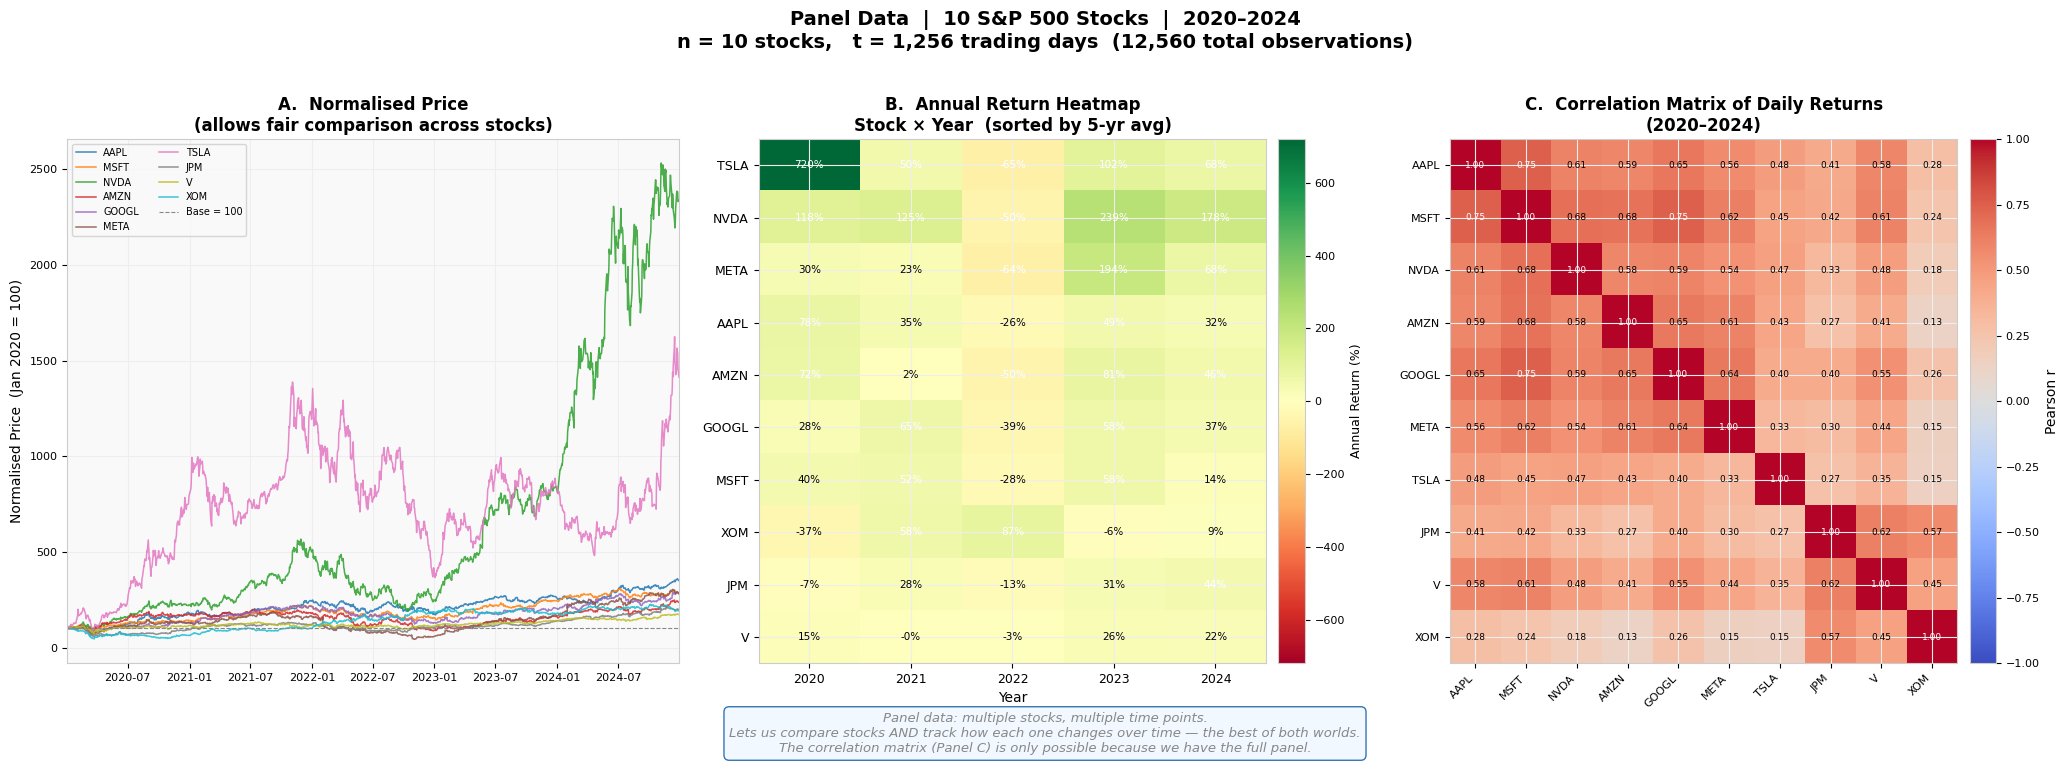

In [20]:
PALETTE = {
    'AAPL':'#1f77b4', 'MSFT':'#ff7f0e', 'NVDA':'#2ca02c', 'AMZN':'#d62728',
    'GOOGL':'#9467bd','META':'#8c564b', 'TSLA':'#e377c2', 'JPM':'#7f7f7f',
    'V':'#bcbd22',    'XOM':'#17becf',
}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    'Panel Data  |  10 S&P 500 Stocks  |  2020–2024\n'
    f'n = 10 stocks,   t = {len(ret10):,} trading days  ({ret10.shape[0]*ret10.shape[1]:,} total observations)',
    fontsize=14, fontweight='bold', y=1.02)

# ── A: all 10 stocks — normalised price (base = 100) ─────────────────────
ax = axes[0]
for tk in TICKERS_10:
    ax.plot(px_norm.index, px_norm[tk],
            color=PALETTE[tk], lw=1.1, alpha=0.85, label=tk)
ax.axhline(100, color=C_GRAY, lw=0.8, ls='--', label='Base = 100')
ax.set_ylabel('Normalised Price  (Jan 2020 = 100)')
ax.set_title('A.  Normalised Price\n(allows fair comparison across stocks)',
             fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.set_xlim(px_norm.index[0], px_norm.index[-1])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

# ── B: heatmap — annual return by stock × year ────────────────────────────
ax = axes[1]
avg_order = ann_ret.mean().sort_values(ascending=False).index.tolist()
heat      = ann_ret[avg_order]
vmax      = max(abs(heat.values.min()), abs(heat.values.max()))
im = ax.imshow(heat.T.values, aspect='auto', cmap='RdYlGn',
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels(heat.index.astype(str), fontsize=9)
ax.set_yticks(range(len(avg_order)))
ax.set_yticklabels(avg_order, fontsize=9)
for i in range(len(heat.index)):
    for j, tk in enumerate(avg_order):
        val = heat.loc[heat.index[i], tk]
        ax.text(i, j, f'{val:.0f}%', ha='center', va='center',
                fontsize=7.5,
                color='black' if abs(val) < 40 else 'white')
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label('Annual Return (%)', fontsize=9)
ax.set_title('B.  Annual Return Heatmap\nStock × Year  (sorted by 5-yr avg)',
             fontweight='bold')
ax.set_xlabel('Year')

# ── C: correlation matrix of daily returns ────────────────────────────────
ax = axes[2]
im2 = ax.imshow(corr.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(TICKERS_10)))
ax.set_xticklabels(TICKERS_10, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(TICKERS_10)))
ax.set_yticklabels(TICKERS_10, fontsize=8)
for i in range(len(TICKERS_10)):
    for j in range(len(TICKERS_10)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=6.5,
                color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
plt.colorbar(im2, ax=ax, label='Pearson r', pad=0.02)
ax.set_title('C.  Correlation Matrix of Daily Returns\n(2020–2024)',
             fontweight='bold')

note = (
    'Panel data: multiple stocks, multiple time points.\n'
    'Lets us compare stocks AND track how each one changes over time — the best of both worlds.\n'
    'The correlation matrix (Panel C) is only possible because we have the full panel.'
)
fig.text(0.5, -0.04, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
plt.tight_layout()
plt.show()


---
## Block 4 — Summary: What Makes Each Structure Different?

The dot grid below shows *which cells of the data matrix are filled*
for each data type.
Blue dots = observations you have.  Grey dots = observations you don't.


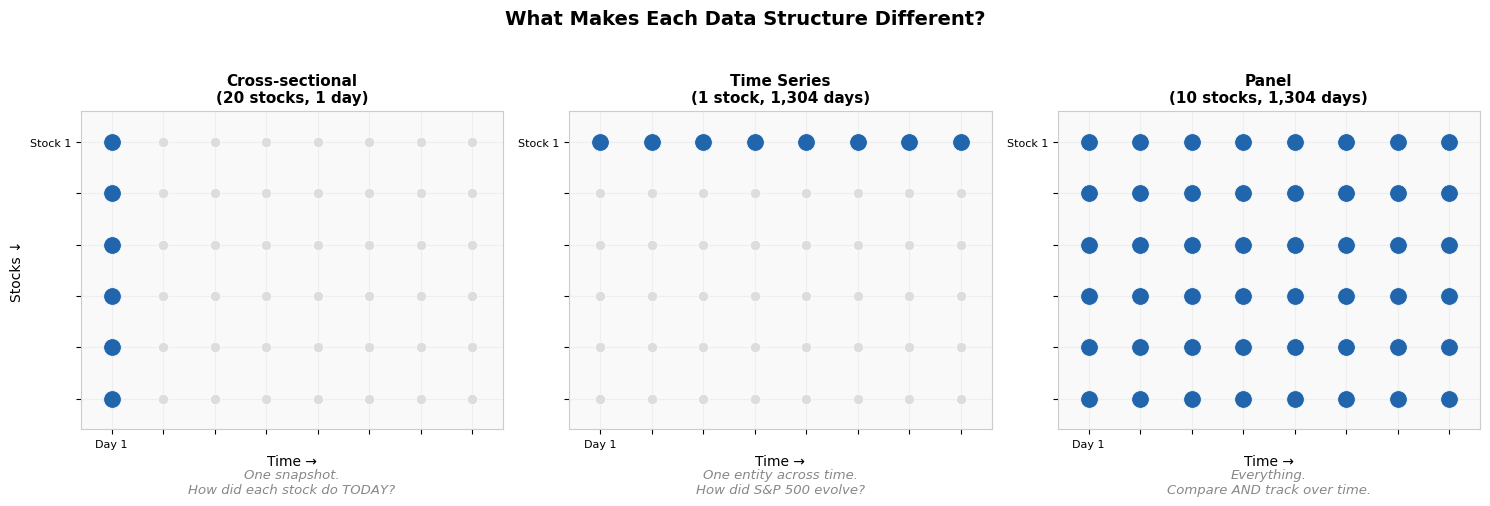

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('What Makes Each Data Structure Different?',
             fontsize=14, fontweight='bold', y=1.03)

def draw_grid(ax, n_rows, n_cols, fill_rows=None, fill_cols=None,
              label_x='', label_y='', title='', note=''):
    for r in range(n_rows):
        for c in range(n_cols):
            obs = (
                (fill_rows is None or r in fill_rows) and
                (fill_cols is None or c in fill_cols)
            )
            ax.scatter(c, -r, s=160 if obs else 55, zorder=3,
                       color=C_BLUE if obs else '#DDDDDD',
                       edgecolors='white', linewidth=0.5)
    ax.set_xlim(-0.6, n_cols - 0.4)
    ax.set_ylim(-n_rows + 0.4, 0.6)
    ax.set_xlabel(label_x, fontsize=10)
    ax.set_ylabel(label_y, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(0, -n_rows, -1))
    ax.set_xticklabels(['Day 1' if i==0 else '' for i in range(n_cols)], fontsize=8)
    ax.set_yticklabels(['Stock 1' if i==0 else '' for i in range(n_rows)], fontsize=8)
    ax.text(0.5, -0.20, note, transform=ax.transAxes,
            ha='center', fontsize=9.5, style='italic', color=C_GRAY)

NR, NC = 6, 8

draw_grid(axes[0], NR, NC, fill_cols=[0],
          label_x='Time →', label_y='Stocks ↓',
          title='Cross-sectional\n(20 stocks, 1 day)',
          note='One snapshot.\nHow did each stock do TODAY?')

draw_grid(axes[1], NR, NC, fill_rows=[0],
          label_x='Time →', label_y='',
          title='Time Series\n(1 stock, 1,304 days)',
          note='One entity across time.\nHow did S&P 500 evolve?')

draw_grid(axes[2], NR, NC,
          label_x='Time →', label_y='',
          title='Panel\n(10 stocks, 1,304 days)',
          note='Everything.\nCompare AND track over time.')

plt.tight_layout()
plt.show()


---
## Dataset Structure Summary


In [22]:
print('DATASET STRUCTURE SUMMARY')
print('─' * 55)
print(f'Cross-sectional : n = {len(cross):>2} stocks,  t =    1 day')
print(f'Time series     : n =  1 index,   t = {len(sp500):,} days')
print(f'Panel           : n = {len(TICKERS_10):>2} stocks,  t = {len(ret10):,} days'
      f'  ({len(ret10)*len(TICKERS_10):,} total rows)')
print()
print('Key takeaway')
print('─' * 55)
print('Cross-sectional → compare across stocks at one moment.')
print('Time series     → follow one stock / index across time.')
print('Panel           → do both simultaneously.')
print()
print('For forecasting: we almost always need TIME in our data.')
print('Cross-sectional alone cannot tell us where a stock is headed.')


DATASET STRUCTURE SUMMARY
───────────────────────────────────────────────────────
Cross-sectional : n = 20 stocks,  t =    1 day
Time series     : n =  1 index,   t = 1,256 days
Panel           : n = 10 stocks,  t = 1,256 days  (12,560 total rows)

Key takeaway
───────────────────────────────────────────────────────
Cross-sectional → compare across stocks at one moment.
Time series     → follow one stock / index across time.
Panel           → do both simultaneously.

For forecasting: we almost always need TIME in our data.
Cross-sectional alone cannot tell us where a stock is headed.


In [23]:
import os

# Create directory if it doesn't exist
fig_dir = "lecture1_figures"
os.makedirs(fig_dir, exist_ok=True)

# Block 1 — Cross-sectional: returns, return vs dollar volume, and distribution
fig1, axes1 = plt.subplots(1, 3, figsize=(19, 6))
fig1.suptitle(
    f'Cross-sectional Data  |  S&P 500 Stocks  |  Snapshot: {SNAP_DATE.strftime("%B %d, %Y")}\n'
    'n = 20 stocks,   t = 1 trading day',
    fontsize=14, fontweight='bold', y=1.02)

# A: horizontal bar — daily returns
ax = axes1[0]
sorted_ret = cross['return_pct'].sort_values()
colors_bar = [C_UP if v >= 0 else C_DOWN for v in sorted_ret]
ax.barh(sorted_ret.index, sorted_ret.values, color=colors_bar, edgecolor='white', linewidth=0.4)
ax.axvline(0, color=C_GRAY, lw=0.9)
ax.set_xlabel('Daily Return (%)')
ax.set_title('A.  Daily Return by Stock', fontweight='bold')
patch_up = mpatches.Patch(color=C_UP, label='Positive return')
patch_down = mpatches.Patch(color=C_DOWN, label='Negative return')
ax.legend(handles=[patch_up, patch_down], fontsize=8)

# B: scatter — dollar volume vs return
ax = axes1[1]
sc = ax.scatter(
    cross['dollar_vol_B'],
    cross['return_pct'],
    s=90, alpha=0.75,
    c=cross['return_pct'], cmap='RdYlGn', vmin=-2, vmax=2,
    edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Daily Return (%)', pad=0.02)
for tk in ['AAPL', 'MSFT', 'NVDA', 'TSLA']:
    if tk in cross.index:
        ax.annotate(tk,
                    (cross.loc[tk,'dollar_vol_B'], cross.loc[tk,'return_pct']),
                    fontsize=7.5, ha='left',
                    xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Dollar Volume (USD billions)')
ax.set_ylabel('Daily Return (%)')
ax.set_title('B.  Return vs Dollar Volume\n(colour = return magnitude)', fontweight='bold')

# C: histogram — distribution of returns
ax = axes1[2]
ax.hist(cross['return_pct'].values, bins=10, color=C_BLUE,
        edgecolor='white', linewidth=0.6, alpha=0.8)
ax.axvline(cross['return_pct'].mean(), color=C_GOLD, lw=2.0, ls='--',
           label=f"Mean = {cross['return_pct'].mean():.2f}%")
ax.axvline(0, color=C_GRAY, lw=1.0, ls=':')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Number of Stocks')
ax.set_title('C.  Distribution of Returns\nacross 20 stocks', fontweight='bold')
ax.legend(fontsize=9)

note = (
    'Cross-sectional data: one row per stock, one point in time.\n'
    'Useful for ranking stocks and comparing them against each other on a given day.\n'
    'Cannot reveal how any stock\'s price changes over time.'
)
fig1.text(0.5, -0.05, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
plt.tight_layout()
fig1.savefig(os.path.join(fig_dir, "block1_cross_sectional.png"), bbox_inches='tight')
plt.close(fig1)

# Block 2 — Time series: price, daily returns, rolling volatility
fig2 = plt.figure(figsize=(16, 10))
gs2 = gridspec.GridSpec(3, 1, figure=fig2, hspace=0.45, height_ratios=[2.5, 1.5, 1.2])
fig2.suptitle(
    'Time-series Data  |  S&P 500 Index  |  2020–2024\n'
    f'n = 1 index,   t = {len(sp500):,} trading days',
    fontsize=14, fontweight='bold', y=1.01)

# A: price level
ax = fig2.add_subplot(gs2[0])
ax.plot(sp500.index, sp500, color=C_BLUE, lw=1.3, label='S&P 500 Price')
ax.fill_between(sp500.index, sp500, sp500.min(), alpha=0.08, color=C_BLUE)
events = [
    ('2020-02-19', 3386, 'Pre-Covid\nAll-time High'),
    ('2020-03-23', 2100, 'Covid\nCrash Bottom'),
    ('2021-11-05', 4698, 'Post-Covid\nAll-time High'),
    ('2022-06-16', 3300, 'Fed Rate\nHike Peak'),
    ('2024-01-19', 4700, '2024\nRally'),
]
for ds, y_ann, lbl in events:
    xv = pd.Timestamp(ds)
    if xv in sp500.index:
        yv = sp500.loc[xv]
    else:
        yv = sp500.asof(xv)
    ax.annotate(lbl, xy=(xv, yv), xytext=(xv, y_ann),
                arrowprops=dict(arrowstyle='->', color=C_GRAY, lw=1.0),
                fontsize=7.5, ha='center', color='black',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#CCCCCC', alpha=0.9))
ax.set_ylabel('Index Level (USD)')
ax.set_title('A.  S&P 500 Price Level with Key Market Events', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=9)
ax.set_xlim(sp500.index[0], sp500.index[-1])

# B: daily returns
ax = fig2.add_subplot(gs2[1])
ax.fill_between(sp_ret.index, sp_ret*100, 0,
                where=sp_ret>=0, color=C_UP,   alpha=0.65, label='Positive')
ax.fill_between(sp_ret.index, sp_ret*100, 0,
                where=sp_ret<0,  color=C_DOWN, alpha=0.65, label='Negative')
ax.axhline(0, color=C_GRAY, lw=0.7)
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-05-01'),
           alpha=0.08, color=C_DOWN, label='High-volatility regime')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color=C_DOWN)
ax.set_ylabel('Daily Return (%)')
ax.set_title('B.  Daily Returns — Volatility Clustering\n'
             '(bad days cluster together; calm periods cluster together)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(sp_ret.index[0], sp_ret.index[-1])

# C: rolling 30-day realised volatility
ax = fig2.add_subplot(gs2[2])
ax.plot(roll_vol.index, roll_vol, color=C_GOLD, lw=1.3,
        label='30-day rolling vol (annualised %)')
ax.fill_between(roll_vol.index, roll_vol, 0, alpha=0.18, color=C_GOLD)
ax.axhline(roll_vol.median(), color=C_GRAY, lw=1.0, ls='--',
           label=f'Median = {roll_vol.median():.1f}%')
ax.set_ylabel('Annualised\nVolatility (%)')
ax.set_title('C.  Rolling 30-Day Realised Volatility', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
ax.set_xlim(roll_vol.index[0], roll_vol.index[-1])
ax.set_xlabel('Date')

note = (
    'Time-series data: one entity, many time points.\n'
    'Reveals long-run trends, volatility regimes, and the impact of macro events.'
)
fig2.text(0.5, -0.03, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
fig2.tight_layout()
fig2.savefig(os.path.join(fig_dir, "block2_time_series.png"), bbox_inches='tight')
plt.close(fig2)

# Block 3 — Panel: normalised prices, annual return heatmap, correlation matrix
PALETTE = {
    'AAPL':'#1f77b4', 'MSFT':'#ff7f0e', 'NVDA':'#2ca02c', 'AMZN':'#d62728',
    'GOOGL':'#9467bd','META':'#8c564b', 'TSLA':'#e377c2', 'JPM':'#7f7f7f',
    'V':'#bcbd22',    'XOM':'#17becf',
}
fig3, axes3 = plt.subplots(1, 3, figsize=(21, 7))
fig3.suptitle(
    'Panel Data  |  10 S&P 500 Stocks  |  2020–2024\n'
    f'n = 10 stocks,   t = {len(ret10):,} trading days  ({ret10.shape[0]*ret10.shape[1]:,} total observations)',
    fontsize=14, fontweight='bold', y=1.02)

# A: all 10 stocks — normalised price (base = 100)
ax = axes3[0]
for tk in TICKERS_10:
    ax.plot(px_norm.index, px_norm[tk],
            color=PALETTE[tk], lw=1.1, alpha=0.85, label=tk)
ax.axhline(100, color=C_GRAY, lw=0.8, ls='--', label='Base = 100')
ax.set_ylabel('Normalised Price  (Jan 2020 = 100)')
ax.set_title('A.  Normalised Price\n(allows fair comparison across stocks)',
             fontweight='bold')
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.set_xlim(px_norm.index[0], px_norm.index[-1])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

# B: heatmap — annual return by stock × year
ax = axes3[1]
avg_order = ann_ret.mean().sort_values(ascending=False).index.tolist()
heat = ann_ret[avg_order]
vmax = max(abs(heat.values.min()), abs(heat.values.max()))
im = ax.imshow(heat.T.values, aspect='auto', cmap='RdYlGn',
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels(heat.index.astype(str), fontsize=9)
ax.set_yticks(range(len(avg_order)))
ax.set_yticklabels(avg_order, fontsize=9)
for i in range(len(heat.index)):
    for j, tk in enumerate(avg_order):
        val = heat.loc[heat.index[i], tk]
        ax.text(i, j, f'{val:.0f}%', ha='center', va='center',
                fontsize=7.5,
                color='black' if abs(val) < 40 else 'white')
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label('Annual Return (%)', fontsize=9)
ax.set_title('B.  Annual Return Heatmap\nStock × Year  (sorted by 5-yr avg)',
             fontweight='bold')
ax.set_xlabel('Year')

# C: correlation matrix of daily returns
ax = axes3[2]
im2 = ax.imshow(corr.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(TICKERS_10)))
ax.set_xticklabels(TICKERS_10, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(TICKERS_10)))
ax.set_yticklabels(TICKERS_10, fontsize=8)
for i in range(len(TICKERS_10)):
    for j in range(len(TICKERS_10)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=6.5,
                color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
plt.colorbar(im2, ax=ax, label='Pearson r', pad=0.02)
ax.set_title('C.  Correlation Matrix of Daily Returns\n(2020–2024)',
             fontweight='bold')

note = (
    'Panel data: multiple stocks, multiple time points.\n'
    'Lets us compare stocks AND track how each one changes over time — the best of both worlds.\n'
    'The correlation matrix (Panel C) is only possible because we have the full panel.'
)
fig3.text(0.5, -0.04, note, ha='center', fontsize=9.5, style='italic', color=C_GRAY,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_BLUE, alpha=0.9))
plt.tight_layout()
fig3.savefig(os.path.join(fig_dir, "block3_panel.png"), bbox_inches='tight')
plt.close(fig3)

# Block 4 — Dot grid summary
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 5))
fig4.suptitle('What Makes Each Data Structure Different?',
             fontsize=14, fontweight='bold', y=1.03)

def draw_grid(ax, n_rows, n_cols, fill_rows=None, fill_cols=None,
              label_x='', label_y='', title='', note=''):
    for r in range(n_rows):
        for c in range(n_cols):
            obs = (
                (fill_rows is None or r in fill_rows) and
                (fill_cols is None or c in fill_cols)
            )
            ax.scatter(c, -r, s=160 if obs else 55, zorder=3,
                       color=C_BLUE if obs else '#DDDDDD',
                       edgecolors='white', linewidth=0.5)
    ax.set_xlim(-0.6, n_cols - 0.4)
    ax.set_ylim(-n_rows + 0.4, 0.6)
    ax.set_xlabel(label_x, fontsize=10)
    ax.set_ylabel(label_y, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(0, -n_rows, -1))
    ax.set_xticklabels(['Day 1' if i==0 else '' for i in range(n_cols)], fontsize=8)
    ax.set_yticklabels(['Stock 1' if i==0 else '' for i in range(n_rows)], fontsize=8)
    ax.text(0.5, -0.20, note, transform=ax.transAxes,
            ha='center', fontsize=9.5, style='italic', color=C_GRAY)

NR, NC = 6, 8
draw_grid(axes4[0], NR, NC, fill_cols=[0],
          label_x='Time →', label_y='Stocks ↓',
          title='Cross-sectional\n(20 stocks, 1 day)',
          note='One snapshot.\nHow did each stock do TODAY?')
draw_grid(axes4[1], NR, NC, fill_rows=[0],
          label_x='Time →', label_y='',
          title='Time Series\n(1 stock, 1,304 days)',
          note='One entity across time.\nHow did S&P 500 evolve?')
draw_grid(axes4[2], NR, NC,
          label_x='Time →', label_y='',
          title='Panel\n(10 stocks, 1,304 days)',
          note='Everything.\nCompare AND track over time.')

plt.tight_layout()
fig4.savefig(os.path.join(fig_dir, "block4_dot_grid.png"), bbox_inches='tight')
plt.close(fig4)